[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Fine-tune PaliGemma2 on Object Detection Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/google-research/big_vision/blob/main/big_vision/configs/proj/paligemma/README.md)
[![arXiv](https://img.shields.io/badge/arXiv-2412.03555-b31b1b.svg)](https://arxiv.org/abs/2412.03555)

PaliGemma 2 is built by combining the SigLIP-So400m vision encoder with the more recent and capable language models from the Gemma 2 family.

![PaliGemma2 Figure.1](https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/paligemma2-1.png)

The authors use a 3-stage training approach similar to the original PaliGemma. In stage 1, they combine the pretrained vision and language model components and train them jointly on a multimodal task mixture. In stage 2, they train the models at higher resolutions of 448px^2 and 896px^2. In stage 3, they fine-tune the models on the target transfer tasks.

PaliGemma 2 models outperform the original PaliGemma at the same resolution and model size. Increasing the model size and resolution generally improves performance across a wide range of tasks, but the benefits differ depending on the task. Some tasks benefit more from increased resolution, while others benefit more from a larger language model.

![PaliGemma2 Figure.2](https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/paligemma2-2.png)

Notebook requires A100 with 40GB of VRAM to train.

## Setup

### Configure your API keys

To fine-tune PaliGemma2, you need to provide your HuggingFace Token and Roboflow API key. Follow these steps:

- Open your [`HuggingFace Settings`](https://huggingface.co/settings) page. Click `Access Tokens` then `New Token` to generate new token.
- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store HuggingFace Access Token under the name `HF_TOKEN`.
    - Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Feb 25 16:42:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:27:00.0 Off |                  N/A |
| 41%   38C    P8             26W /  350W |       4MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download dataset from Roboflow Universe

To fine-tune PaliGemma2, prepare your dataset in JSONL format. You can use Roboflow to easily convert any dataset into this format.

In [2]:
#%pip install transformers==4.48.0 accelerate==1.3.0 (this is what I currently use)

#%pip install -q peft bitsandbytes transformers==4.47.0 tf-keras
#%pip install git+https://github.com/huggingface/transformers
#%pip install git+https://github.com/huggingface/accelerate

**NOTE:** Let's read the first few lines of the annotation file and examine the dataset format.

### Set up and test data loaders

/home/argusm/local/miniconda3/envs/paligemma/lib/python3.12/site-packages/sapien/_vulkan_tricks.py:21: UserWarning: Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.
  warn("Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.")


dataset_location /tmp/clevr-act-7-depth



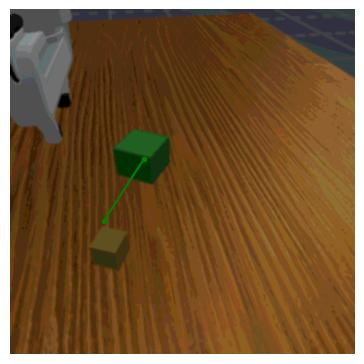
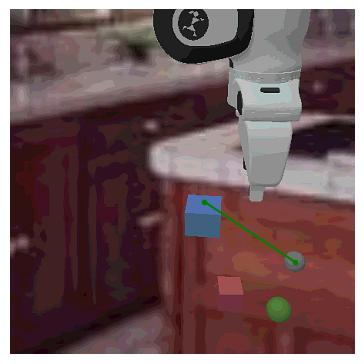
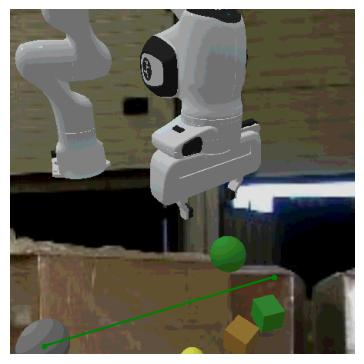
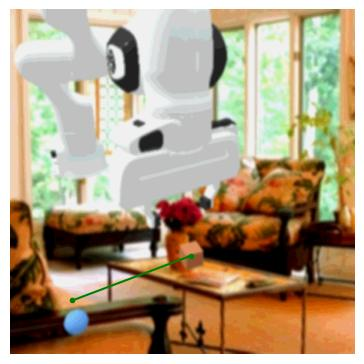
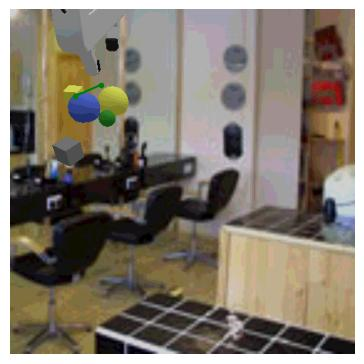
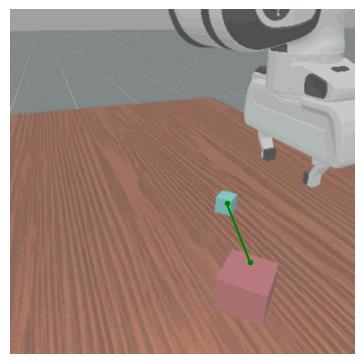
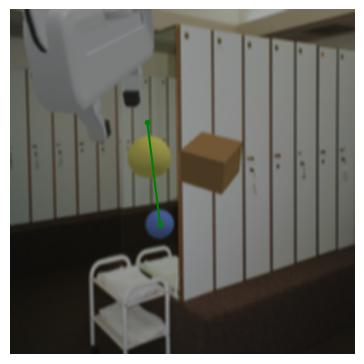
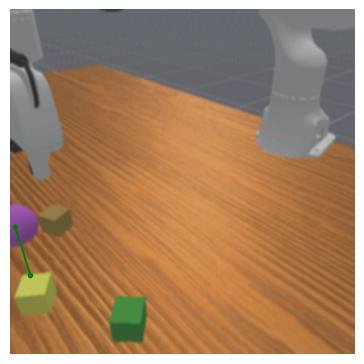
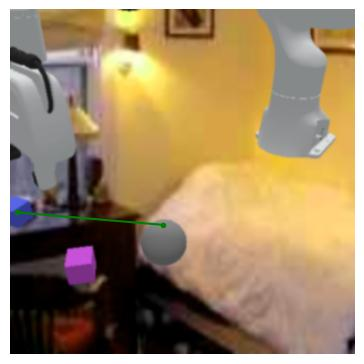
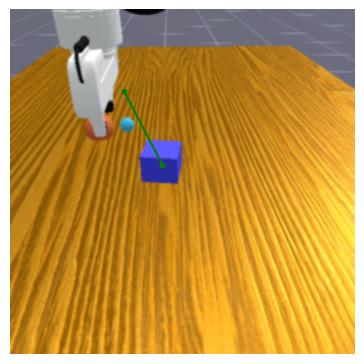
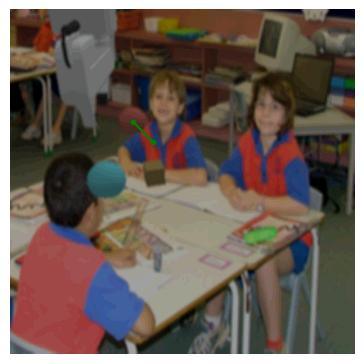
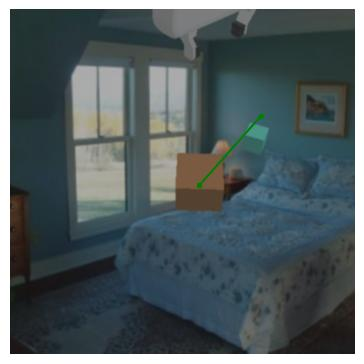

In [1]:
import os
import random
from pathlib import Path
from PIL import Image

from utils_vis import render_example
from utils_trajectory import DummyCamera

from data_loader_h5 import H5Dataset
from data_loader_images import ImageFolderDataset
from torchvision import transforms

os.environ["CUDA_VISIBLE_DEVICES"]="0,1"



from data_augmentations import RandomizeBackgrounds, augment_image_rgb, complexify_text
dataset_location = Path("/tmp/clevr-act-7-depth")

bg_image_dataset = ImageFolderDataset("/tmp/indoorCVPR/Images", transform=transforms.RandomResizedCrop((448,448)))
randomize_background = RandomizeBackgrounds(p=0.6, background_images = bg_image_dataset)
train_dataset = H5Dataset(dataset_location, augment_rgbds=randomize_background, augment_rgb=augment_image_rgb, augment_text=complexify_text)
model_location = Path("/data/lmbraid19/argusm/models")

print("dataset_location", dataset_location)

num_samples = 3*4
html_imgs = ""
for i in range(num_samples):
    image, sample = train_dataset[i]
    prefix = sample["prefix"]
    html_imgs += render_example(image, label=sample["suffix"], text=prefix, camera=sample["camera"])

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

### Load PaliGemma2 model

**NOTE:** PaliGemma2 offers 9 pre-trained models with sizes of `3B`, `10B`, and `28B` parameters, and resolutions of `224`, `448`, and `896` pixels. In this tutorial, I'll be using the [`google/paligemma2-3b-pt-448`](https://huggingface.co/google/paligemma2-3b-pt-448) checkpoint. Resolution has a key impact on the mAP of the trained model, and it seems that `448` offers the most optimal balance between performance and compute resources required to train the model.

In [4]:
#from huggingface_hub import notebook_login
#notebook_login()

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0,1"
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration
import torch

# setting device on GPU if available, else CPU
print("cuda visible devices:", os.environ["CUDA_VISIBLE_DEVICES"])
devices_good = sorted((int(x) for x in os.environ["CUDA_VISIBLE_DEVICES"].split(",")))
DEVICE = torch.device('cuda')
print(DEVICE)
print('Using device:', DEVICE)
print("Good devices", devices_good)

TORCH_DTYPE = torch.bfloat16
MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
model = PaliGemmaForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=TORCH_DTYPE, device_map="auto", attn_implementation='eager')

2025-02-25 16:42:24.219596: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740498144.239011 3758452 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740498144.244876 3758452 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-25 16:42:24.264446: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


cuda visible devices: 0,1
cuda
Using device: cuda
Good devices [0, 1]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [6]:
import requests
from PIL import Image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg?download=true"
image = Image.open(requests.get(url, stream=True).raw)

# Instruct the model to create a caption in Spanish
prompt = "caption en"
model_inputs = processor(text=prompt, images=image, return_tensors="pt")
input_len = model_inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**model_inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]
    decoded = processor.decode(generation, skip_special_tokens=True)
    print(decoded)
assert decoded == "automobile model is a classic car ."

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
The 'batch_size' attribute of HybridCache is deprecated and will be removed in v4.49. Use the more precisely named 'self.max_batch_size' attribute instead.
/home/argusm/local/miniconda3/envs/paligemma/lib/python3.12/site-packages/transformers/generation/utils.py:2137: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warni

automobile model is a classic car .


In [7]:
def augment_suffix(suffix):
    parts = suffix.split(' ; ')
    random.shuffle(parts)
    return ' ; '.join(parts)

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    suffixes = [augment_suffix(label["suffix"]) for label in labels]

    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        suffix=suffixes,
        padding="longest"
    ).to(TORCH_DTYPE)#.to(DEVICE)

    return inputs

## Fine-tune with JAX settings

In [8]:
import numpy as np
def compute_metrics(eval_pred):
    predictions, label_tokens = eval_pred  # Extract predictions and labels
    if isinstance(predictions, tuple):  # Some models return tuples
        predictions = predictions[0]

    # Convert to token indices if necessary (e.g., for text generation models)
    pred_tokens = np.argmax(predictions, axis=-1)  # Assuming logits, take argmax

    pred_texts = processor.tokenizer.batch_decode(pred_tokens[:,-SEQLEN-1:], skip_special_tokens=True)
    label_text = processor.tokenizer.batch_decode(label_tokens[:,-SEQLEN-1:], skip_special_tokens=True)

    print(pred_tokens[:,-SEQLEN-1:])
    print(label_tokens[:,-SEQLEN-1:])
    print(label_text)
    print(pred_texts)
    print()
    return {"accuracy": 0}

In [9]:
%reload_ext autoreload
%autoreload 2
from transformers import Seq2SeqTrainingArguments
from transformers import Seq2SeqTrainer

for param in model.vision_tower.parameters():
    param.requires_grad = False

for param in model.multi_modal_projector.parameters():
    param.requires_grad = False
    
for name, param in model.named_parameters():
    if param.requires_grad == True:
        if "self_attn" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

TRAIN_EXAMPLES = len(train_dataset)
BATCH_SIZE = 32
BATCH_SIZE_DEV = 8
GRAD_ACCUM = int(round(BATCH_SIZE / BATCH_SIZE_DEV))
TRAIN_STEPS = (TRAIN_EXAMPLES // BATCH_SIZE)
SEQLEN = 12
SAVE_STEPS = int(TRAIN_STEPS / 15)
SAVE_LIMIT = 5


save_path = model_location / (str(Path(dataset_location).stem) + "_rbg60")
print("save_path", save_path)
print("TRAIN_STEPS",TRAIN_STEPS)
print("GRAD_ACCUM", GRAD_ACCUM)

args_jax = Seq2SeqTrainingArguments(
    max_steps=TRAIN_STEPS,
    remove_unused_columns=False,
    per_device_train_batch_size=BATCH_SIZE_DEV,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=3e-5,  # 1e-5, 2e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=.05,
    generation_max_length=SEQLEN,
    logging_steps=10,
    optim="adafactor",
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_LIMIT,
    output_dir=save_path,
    bf16=True,
    report_to=["tensorboard"],
    dataloader_pin_memory=False,
    dataloader_num_workers=4,
    #dataloader_prefetch_factor=2,
    #eval_strategy="steps",
    #eval_steps=4,
    #per_device_eval_batch_size=BATCH_SIZE_DEV,
    #eval_accumulation_steps=GRAD_ACCUM
)
#gradient_checkpointing=True,
#weight_decay=3e-7,
#     
trainer = Seq2SeqTrainer(
    model=model,
    train_dataset=train_dataset,
    #eval_dataset=train_dataset,
    data_collator=collate_fn,
    args=args_jax,
    compute_metrics=compute_metrics
)

save_path /data/lmbraid19/argusm/models/clevr-act-7-depth_text_aug
TRAIN_STEPS 4687
GRAD_ACCUM 4


In [10]:
#trainer.save_model(save_path / "checkpoint-start")
trainer.train()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Step,Training Loss
10,14.548100
20,13.686800
30,10.577400
40,7.488800
50,5.668800
60,4.725700
70,4.248400
80,3.996100
90,3.739400
100,3.587200


TrainOutput(global_step=4687, training_loss=1.7214935922103827, metrics={'train_runtime': 15437.3372, 'train_samples_per_second': 9.716, 'train_steps_per_second': 0.304, 'total_flos': 6.367076105578099e+17, 'train_loss': 1.7214935922103827, 'epoch': 0.9998933333333333})

In [11]:

import sys; import torch; import transformers; import tokenizers; import accelerate; \
print('Python Version:', sys.version); \
print('Torch Version:', torch.__version__); \
print('CUDA Available:', torch.cuda.is_available()); \
print('CUDA Device Count:', torch.cuda.device_count()); \
print('GPU Name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'); \
print('Transformers Version:', transformers.__version__); \
print('Tokenizers Version:', tokenizers.__version__); \
print('Accelerate Version:', accelerate.__version__)

[autoreload of data_loader_h5 failed: Traceback (most recent call last):
  File "/home/argusm/local/miniconda3/envs/paligemma/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/argusm/local/miniconda3/envs/paligemma/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/home/argusm/local/miniconda3/envs/paligemma/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/ihome/argusm/lang/cVLA/data_loader_h5.py", line 11, in <module>
    from data_augmentations import depth_to_color
ImportError: cannot import name 'depth_to_color' from 'data_augmen

Python Version: 3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 16:05:46) [GCC 13.3.0]
Torch Version: 2.6.0+cu124
CUDA Available: True
CUDA Device Count: 2
GPU Name: NVIDIA GeForce RTX 3090
Transformers Version: 4.48.0
Tokenizers Version: 0.21.0
Accelerate Version: 1.3.0


In [12]:
#print(save_path)
#

In [13]:
# from tqdm.notebook import tqdm
# test_samples = 5
# decode_dataset = [None, ]*test_samples
# for i in tqdm(range(test_samples), total=test_samples):
#     image, label = train_dataset[i]
#     prefix = "<image>" + label["prefix"]
#     suffix = label["suffix"]
#     inputs = processor(
#         text=prefix,
#         images=image,
#         return_tensors="pt",
#         suffix = [augment_suffix(suffix)]
#     ).to(TORCH_DTYPE).to(DEVICE)
#     prefix_length = inputs["input_ids"].shape[-1]

#     with torch.inference_mode():
#         generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
#         generation = generation[0][prefix_length:]
#         decoded = processor.decode(generation, skip_special_tokens=True)
#     print(suffix)
#     print(decoded)
#     print()

### Run inference with fine-tuned PaliGemma2 model

In [14]:
# Load files
#model = PaliGemmaForConditionalGeneration.from_pretrained(save_path)

In [15]:
from tqdm.notebook import tqdm

def augment_suffix(suffix):
    parts = suffix.split(' ; ')
    random.shuffle(parts)
    return ' ; '.join(parts)

test_samples = 25
decode_dataset = [None, ]*test_samples
for i in tqdm(range(test_samples), total=test_samples):
    image, label = test_dataset[i]
    prefix = "<image>" + label["prefix"]
    suffix = label["suffix"]
    inputs = processor(
        text=prefix,
        images=image,
        return_tensors="pt",
        suffix = [augment_suffix(suffix)]
    ).to(TORCH_DTYPE).to(DEVICE)
    prefix_length = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
        generation = generation[0][prefix_length:]
        decoded = processor.decode(generation, skip_special_tokens=True)
    decode_dataset[i] = decoded

print(decode_dataset)

  0%|          | 0/25 [00:00<?, ?it/s]

NameError: name 'test_dataset' is not defined

In [ ]:
import numpy as np
class ModelWrapper:
    def __init__(self, transformers_model=model):
        self.model = transformers_model
    
    def make_predictions(self, image, prefix):
        prefix = "<image>" + prefix
        image = Image.fromarray(image)
        inputs = processor(text=prefix,
                           images=image,
                           return_tensors="pt").to(TORCH_DTYPE).to(DEVICE_0)
        prefix_length = inputs["input_ids"].shape[-1]
        with torch.inference_mode():
            generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
            generation = generation[0][prefix_length:]
            decoded = processor.decode(generation, skip_special_tokens=True)
        return None, None, None, decoded
model_wrapped = ModelWrapper(model)

i = 0
image, label = test_dataset[i]
print(image)
print(label["prefix"])
res = model_wrapped.make_predictions(np.asarray(image), label["prefix"])
print(res)


In [ ]:
%reload_ext autoreload
%autoreload 2
import json
from PIL import Image
from mani_skill.examples.run_env import Args, iterate_env, save_dataset

        
parsed_args = Args()
parsed_args.env_id = "ClevrMove-v1"
parsed_args.render_mode = "rgb_array"
parsed_args.control_mode = "pd_joint_pos"

env_iter = iterate_env(parsed_args, vis=False, model=model_wrapped)

In [ ]:
for i in range(50):
    next(env_iter)

# Some code to figure out inputs

Looks like the first 256 tokens (i.e. 16x16) will get replaced with the outputs of the image encoder.

In [ ]:
image, label = test_dataset[1]
prefix = "<image>" + label["prefix"]
suffix = label["suffix"]


inputs = processor(
    text=prefix,
    images=image,
    return_tensors="pt",
    #suffix = [augment_suffix(suffix)]
)

#print(label["suffix"])
#print(decoded)
for input_name, input in inputs.items():
    print(input_name, input.shape)
extra = 273 - 256 
print(extra, extra**.5)
print(inputs["input_ids"][:, 256:])


print(processor.decode(inputs["input_ids"][0, 256:]))
tmp = processor.decode([108])
#print(processor.tokenizer.eos_token)
#print(processor.image_token_id)

In [ ]:
# Find where parameters are located

from collections import defaultdict
param_locations = defaultdict(list)
for i in model.named_parameters():
    #print(f"{i[0]} -> {i[1].device}")
    param_locations[f"{i[1].device}"]= f"{i[0]}"

for k, v in param_locations.items():
    print(k, len(v))

#print(DEVICE)

In [ ]:
# #Additional Info when using cuda
# import torch
# for i in range(torch.cuda.device_count()):
#    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
#    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
#    print(torch.cuda.get_device_properties(i).name, )


In [ ]:
print("cuda visible devices:", os.environ["CUDA_VISIBLE_DEVICES"])
DEVICE = torch.device('cuda')
model = PaliGemmaForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=TORCH_DTYPE, device_map="auto")

batch = [valid_dataset[i] for i in range(8)]
inputs = collate_fn(batch)
#generate_ids = model.generate(**inputs, max_length=286+30)
trainer.model.train()
trainer.compute_loss(model, inputs, return_outputs=False, num_items_in_batch=416)
print("works")
trainer.model.train(False)
trainer.compute_loss(model, inputs, return_outputs=False, num_items_in_batch=416)
print("fails.")

In [ ]:
batch = [valid_dataset[i] for i in range(8)]
inputs = collate_fn(batch)
#generate_ids = model.generate(**inputs, max_length=286+30)
trainer.model.train()
trainer.compute_loss(model, inputs, return_outputs=False, num_items_in_batch=416)
print("works")
trainer.model.train(False)
trainer.compute_loss(model, inputs, return_outputs=False, num_items_in_batch=416)
print("fails.")

#raise ValueError
#pass
# orig_context_manager = trainer.compute_loss_context_manager
# class TempTrainContext(object):
#     def __init__(self, trainer):
#         self.trainer = trainer
#         self.orig_context_manager = trainer.compute_loss_context_manager
#     def __enter__(self):
#         self.orig_context_inst = self.orig_context_manager()
#         self.orig_context_inst.__enter__()
#         self.training_enter = self.trainer.model.training
#         self.trainer.model.train()
#     def __exit__(self, type, value, traceback):
#         self.trainer.model.train(self.training_enter)
#         self.orig_context_inst.__exit__(type, value, traceback)
#     def __call__(self):
#         return self
# trainer.compute_loss_context_manager = TempTrainContext(trainer)

## Fine-tune PaliGemma2 using LoRA

In [ ]:
# # @title Freeze the image encoder

# TORCH_DTYPE = torch.bfloat16
# #model = PaliGemmaForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=TORCH_DTYPE).to(DEVICE)
# model = PaliGemmaForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=TORCH_DTYPE, device_map="auto")## max_memory={1:"25GB",})# 5:"25GB", 6:"25GB"})  # was auto

# for param in model.vision_tower.parameters():
#     param.requires_grad = False

# for param in model.multi_modal_projector.parameters():
#     param.requires_grad = False

In [ ]:
# # @title Fine-tune the entire model with LoRA and QLoRA
# from transformers import BitsAndBytesConfig
# from peft import get_peft_model, LoraConfig

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.bfloat16
# )

# lora_config = LoraConfig(
#     r=8,
#     target_modules=["q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"],
#     task_type="CAUSAL_LM",
# )
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

In [ ]:
# from transformers import Trainer, TrainingArguments, Seq2SeqTrainingArguments

# TRAIN_EXAMPLES = len(train_dataset.entries)
# BATCH_SIZE = 18
# BATCH_SIZE_DEV = 6
# GRAD_ACCUM = BATCH_SIZE // BATCH_SIZE_DEV

# TRAIN_STEPS = TRAIN_EXAMPLES // BATCH_SIZE
# SAVE_STEPS = TRAIN_STEPS // 8
# SEQLEN = 32

# args_lora = Seq2SeqTrainingArguments(
#     num_train_epochs=1,
#     remove_unused_columns=False,
#     per_device_train_batch_size=BATCH_SIZE_DEV,
#     gradient_accumulation_steps=GRAD_ACCUM,
#     #gradient_checkpointing=True, use_cache=False,
#     generation_max_length=SEQLEN,
#     warmup_steps=2,
#     learning_rate=.005#2e-5,
#     weight_decay=1e-6,
#     adam_beta2=0.999,
#     logging_steps=10,
#     optim="adamw_hf",
#     save_strategy="steps",
#     save_steps=1000,
#     save_total_limit=1,
#     output_dir=save_path,
#     bf16=True,
#     report_to=["tensorboard"],
#     dataloader_pin_memory=False
# )

# trainer = Trainer(
#     model=model,
#     train_dataset=train_dataset,
#     #eval_dataset=valid_dataset,
#     data_collator=collate_fn,
#     args=args_lora
# )

# trainer.train()
#print(save_path)
#trainer.save_model(save_path)